In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Distribution embedding

In [2]:
real_dist = np.random.normal(loc=0.0, scale=1.0, size = 1000)

In [3]:
def norm_binning(_data, _nbins):
    
    data_interval = max(_data) - min(_data)
    bin_length = float(data_interval)/float(_nbins)
    
    binned_data = {}
    for b in range(_nbins):
        bin_min_val = min(_data) + bin_length * b
        bin_max_val = min(_data) + bin_length * (b+1)
        
        bin_counts = sum(1 for x in _data if bin_min_val <= x < bin_max_val)
        if b == _nbins-1: 
            bin_counts += sum(1 for x in _data if x == bin_max_val)

        binned_data.update({format(int(b), f'0{int(np.log2(_nbins))}b') : bin_counts})
    return binned_data

(array([ 10.,  49., 166., 299., 259., 164.,  42.,  11.]),
 array([-3.26426919e+00, -2.44772148e+00, -1.63117377e+00, -8.14626065e-01,
         1.92164316e-03,  8.18469351e-01,  1.63501706e+00,  2.45156477e+00,
         3.26811248e+00]),
 <BarContainer object of 8 artists>)

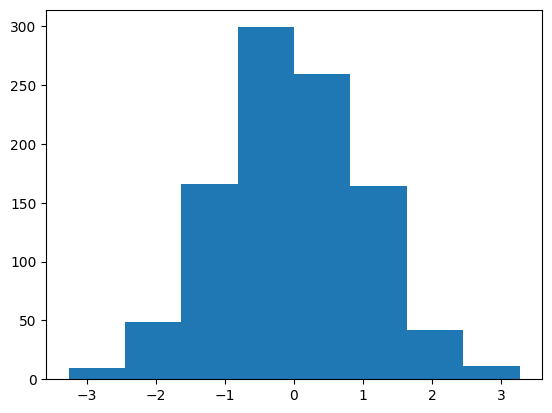

In [4]:
plt.hist(real_dist, bins = 8)

In [5]:
nbins = 8 # Always power of 2
binned = norm_binning(real_dist,nbins)
print(binned)
print(sum([binned[b] for b in binned]))

{'000': 10, '001': 49, '010': 166, '011': 299, '100': 259, '101': 164, '110': 42, '111': 10}
999


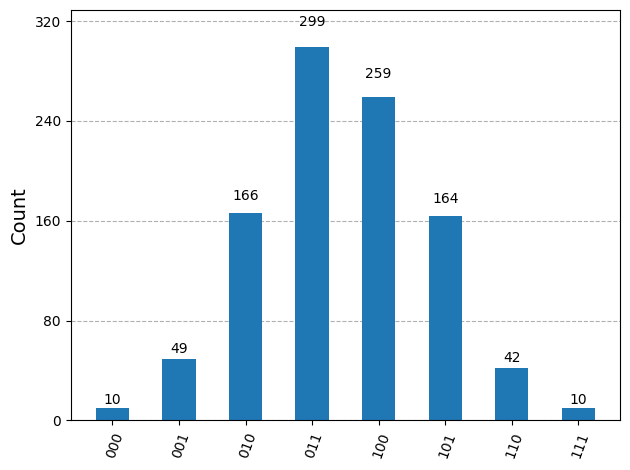

In [6]:
plot_histogram(binned)

In [7]:
def dist(_size):
    return np.random.normal(loc = 1.0, scale = 1.0, size = _size)

def sample_dist(_size, _nbins):
    _sample = dist(_size)
    return norm_binning(_sample, _nbins)    

(array([ 21.,  78., 259., 324., 210.,  89.,  17.,   2.]),
 array([-2.0075188 , -1.1554331 , -0.30334741,  0.54873829,  1.40082399,
         2.25290969,  3.10499538,  3.95708108,  4.80916678]),
 <BarContainer object of 8 artists>)

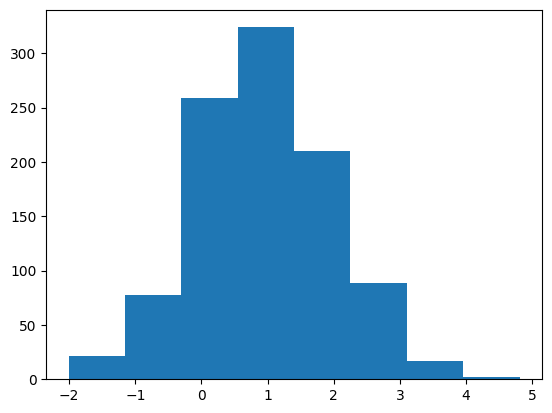

In [8]:
plt.hist(dist(1000), bins = nbins)

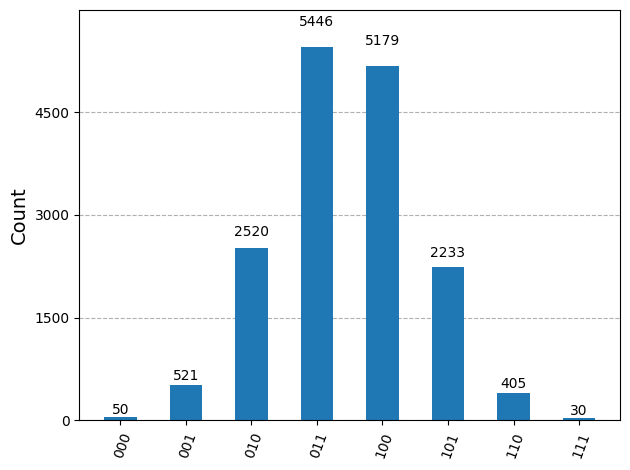

In [9]:
plot_histogram(sample_dist(2**14, nbins))

# QGAN evaluation

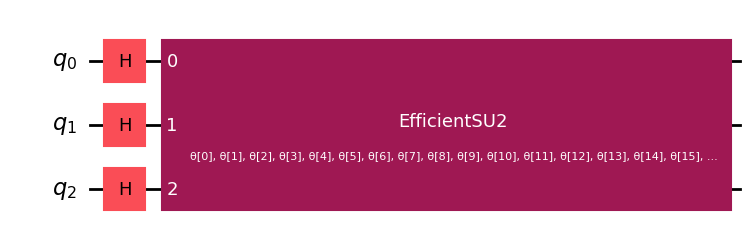

In [10]:
from qiskit.circuit.library import efficient_su2
num_qubits = int(np.log2(nbins))

qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
esu2_gate = efficient_su2(num_qubits = num_qubits, reps = 2).to_gate()
qc.append(esu2_gate, range(num_qubits))
    
qc.draw('mpl')

In [11]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer


discriminator = Sequential([InputLayer(input_shape=(nbins,)),
                            Dense(32, activation='tanh'),
                            Dense(32, activation='tanh'),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

2026-03-07 10:50:45.980751: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 10:50:46.022721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772877046.077348  198169 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772877046.093415  198169 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772877046.137339  198169 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from qgan import QGAN

In [13]:
model = QGAN(num_qubits =int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [14]:
epochs = 2000
model.fit(epochs = epochs, opt = 'COBYLA', manager = True, maxiter = 2*qc.num_parameters, tol = 1e-8)

Monitoring run: run_20260307_105050
Training started


100%|██████████| 2000/2000 [1:01:23<00:00,  1.84s/it]

Training completed


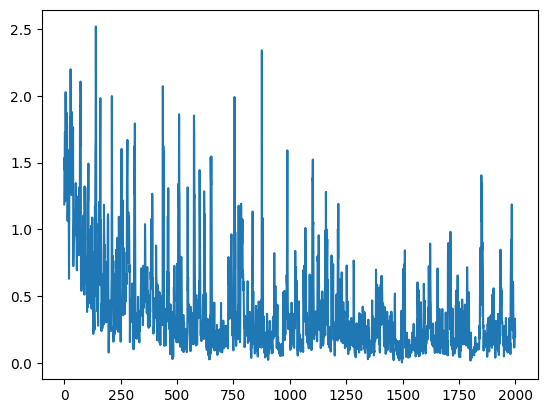

In [15]:
plt.plot(model.metrics['kullback_leibler'])

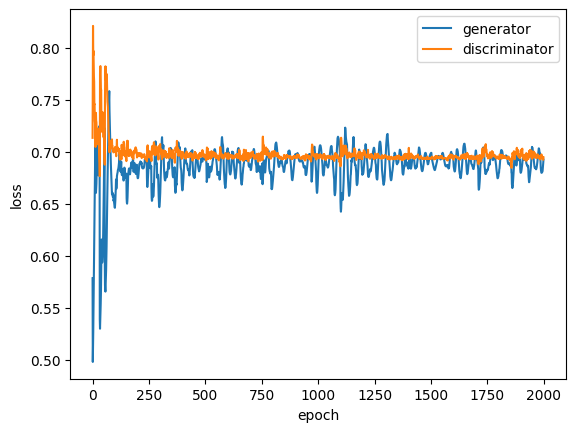

In [16]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

In [17]:
nsamples = 2**14
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)
print(f'KS score: {model.scoreKS(nsamples)}')
print(f'KS 0.1: {1.22/(nsamples)**(0.5)}')
print(f'KS 0.05: {1.36/(nsamples)**(0.5)}')
print(f'KS 0.01: {1.63/(nsamples)**(0.5)}')

KS score: 3.17578125
KS 0.1: 0.00953125
KS 0.05: 0.010625
KS 0.01: 0.012734375


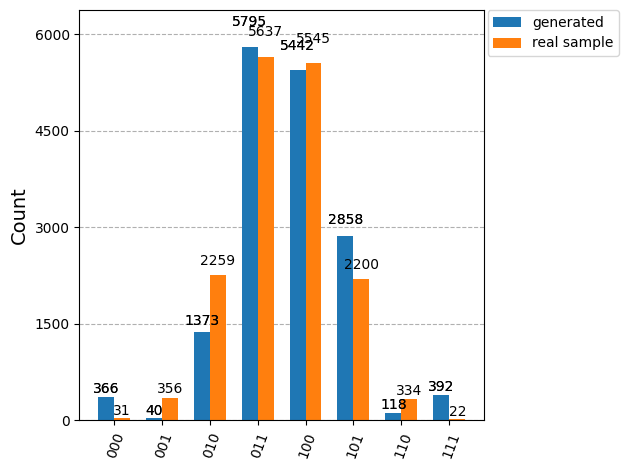

In [18]:
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])

# Ansatz with correlation layers

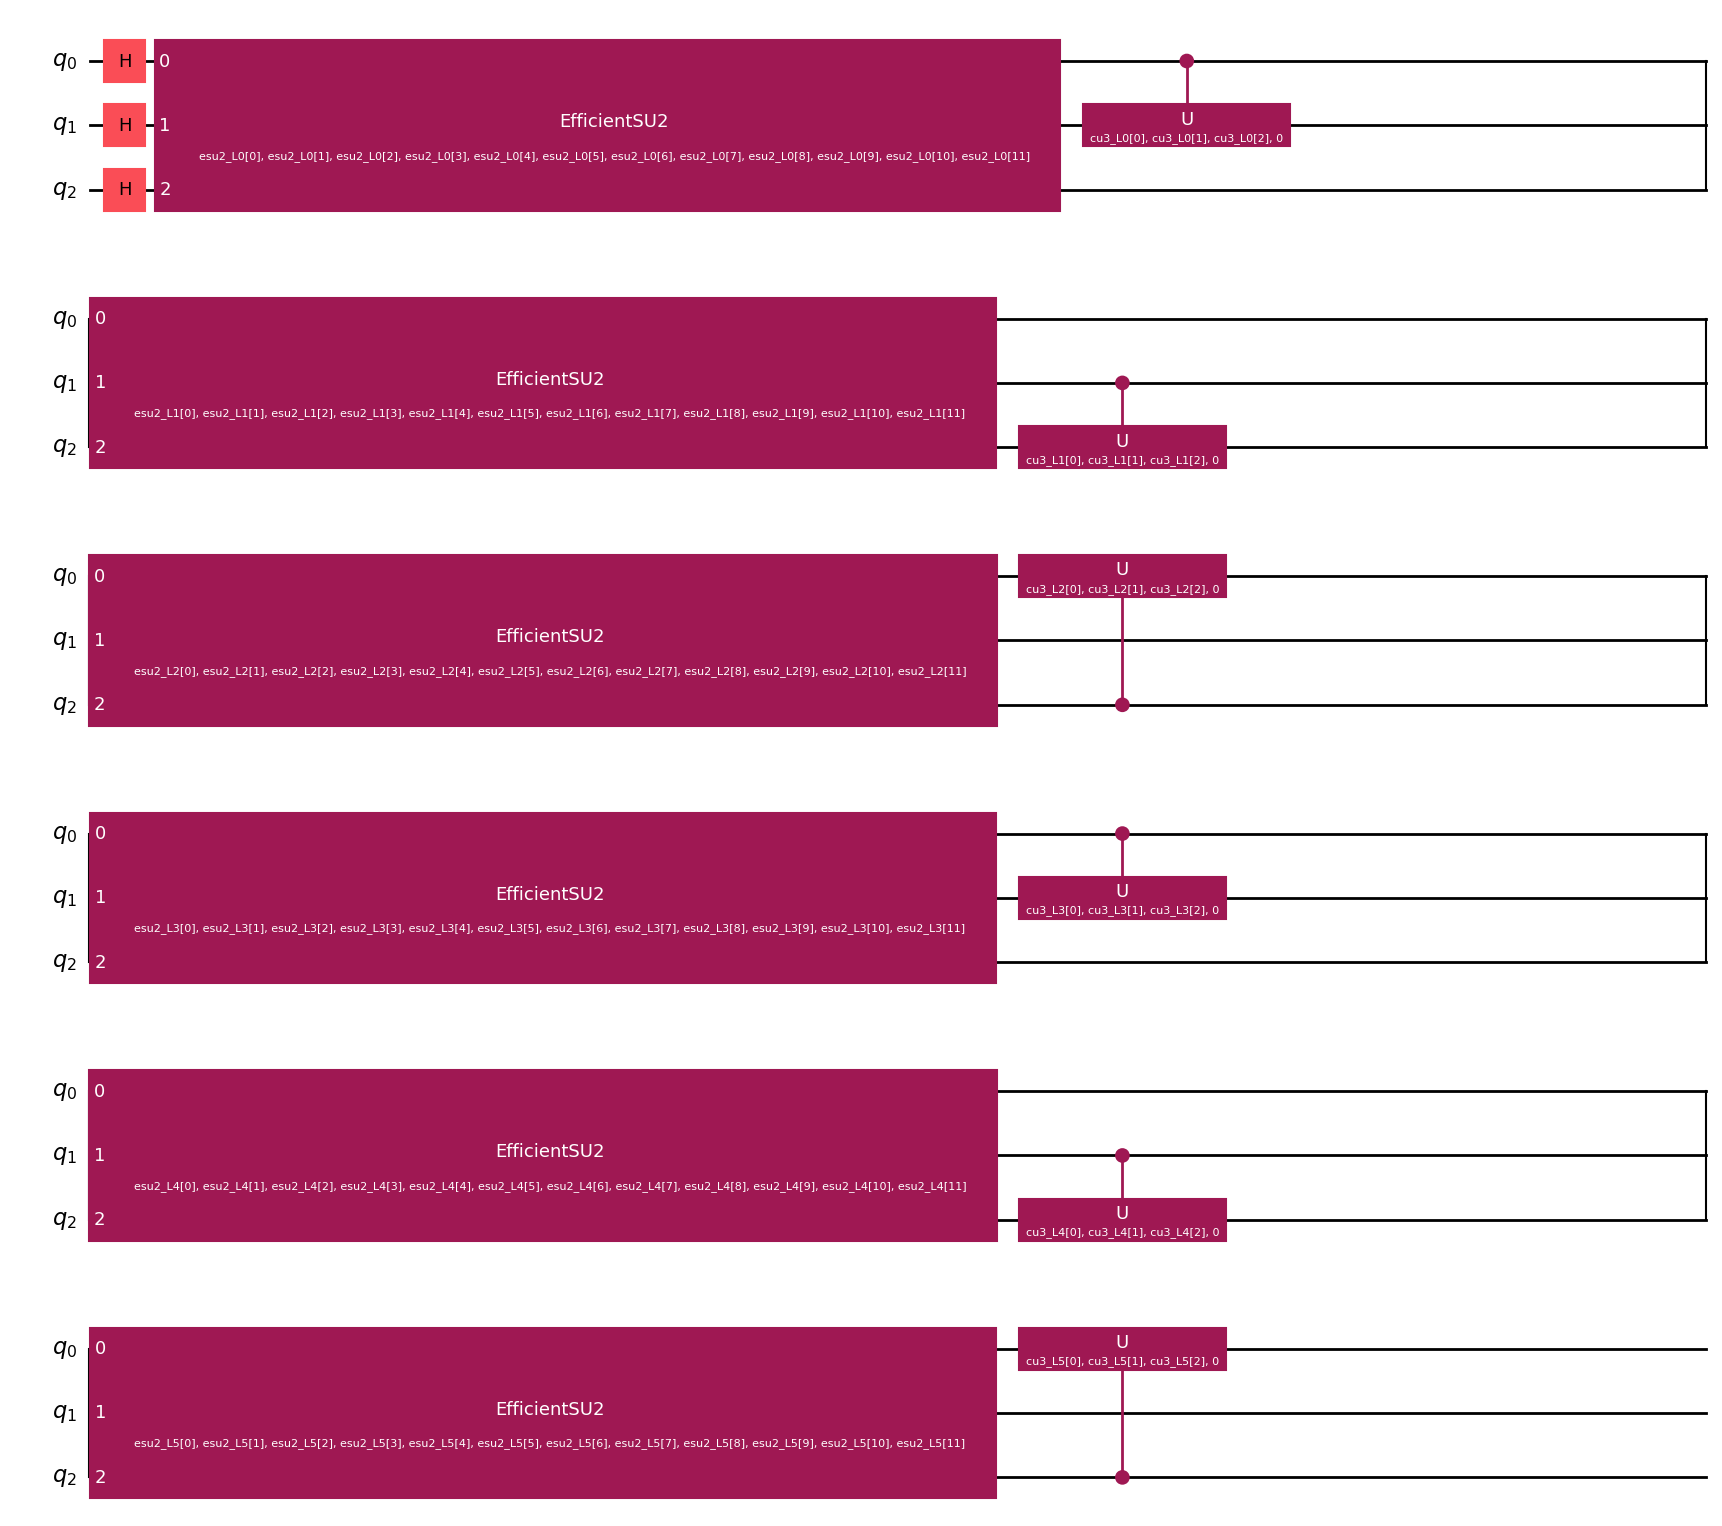

In [19]:
from qiskit.circuit.library import efficient_su2
from qiskit.circuit import ParameterVector
num_qubits = int(np.log2(nbins))

qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
for i in range(6):
    esu2_gate = efficient_su2(num_qubits = num_qubits, su2_gates=['rx', 'ry'], reps = 1, parameter_prefix=f'esu2_L{i}').to_gate()
    layer_name = f'cu3_L{i}'
    cu3_params = ParameterVector(layer_name, length = 3)
    qc.append(esu2_gate, range(num_qubits))
    qc.cu(cu3_params[0], cu3_params[1], cu3_params[2], 0, i%num_qubits, (i+1)%num_qubits)

        
qc.draw('mpl')

In [20]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer


discriminator = Sequential([InputLayer(input_shape=(nbins,)),
                            Dense(128, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(128, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

/usr/local/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model = QGAN(num_qubits = num_qubits,
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [22]:
epochs = 1000
model.fit(epochs = epochs, opt = 'COBYLA', )

Training started


  5%|▌         | 51/1000 [10:32<3:16:15, 12.41s/it]


KeyboardInterrupt: 

In [ ]:
plt.plot(range(epochs), model.generator_losses, label = 'generator')
plt.plot(range(epochs), model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
nsamples = 2**14
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)

In [ ]:
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])

In [ ]:
plt.plot(range(epochs), model.metrics['kullback_leibler'])

# Real amplitudes

In [ ]:
from qiskit.circuit.library import TwoLocal
num_qubits = int(np.log2(nbins))

qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
ra_gate = TwoLocal(num_qubits, 
                     rotation_blocks=['ry'], 
                     entanglement_blocks='cz', 
                     entanglement='full', 
                     reps = 6).to_gate()
qc.append(ra_gate, range(num_qubits))
    
qc.draw('mpl')

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer


discriminator = Sequential([InputLayer(input_shape=(nbins,)),
                            Dense(64, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(64, activation='tanh', kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.L2(1e-3)),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

In [ ]:
model = QGAN(num_qubits = num_qubits,
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [ ]:
epochs = 1000
model.fit(epochs = epochs)

In [ ]:
nsamples = 2**14
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)

In [ ]:
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])

In [ ]:
plt.plot(range(epochs), model.metrics['kullback_leibler'])